In [3]:
import os
import re
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


W0517 18:18:44.646000 849460 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0517 18:18:44.657000 849460 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


🦥 Unsloth Zoo will now patch everything to make training faster!


<string>:1: FutureWarning: torch._dynamo.config.inline_inbuilt_nn_modules is deprecated and does not do anything, inline_inbuilt_nn_modules is always True. It will be removed in a future version of PyTorch.


In [4]:
# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # Llama 3.2 vision support
    "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
    "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # Can fit in a 80GB card!
    "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

    "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral fits in 16GB!
    "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral base model

    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # Qwen2 VL support
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # Any Llava variant works!
    "unsloth/llava-1.5-7b-hf-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-8B-Instruct-unsloth-bnb-4bit",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

==((====))==  Unsloth 2026.3.11: Fast Qwen3_Vl patching. Transformers: 4.57.1.
   \\   /|    NVIDIA GeForce RTX 3090. Num GPUs = 2. Max memory: 23.588 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.12.0+cu126. CUDA: 8.6. CUDA Toolkit: 12.6. Triton: 3.7.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.11it/s]


In [6]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

RuntimeError: Unsloth: You already added LoRA adapters to your model!

## data

In [1]:
import json
from pathlib import Path
from datasets import Dataset, DatasetDict, Image as HFImage, load_from_disk
from PIL import Image
import imageio.v3 as iio
from tqdm.auto import tqdm

DATASET_CACHE = Path("../rt1_data/dataset_cache")

def sample_frames(video_path: str) -> list:
    """Extract 4 evenly spaced frames: first, two middle, last."""
    frames = iio.imread(video_path, plugin="pyav")
    n = len(frames)
    if n < 4:
        indices = list(range(n))
    else:
        indices = [0, n // 3, 2 * n // 3, n - 1]
    return [Image.fromarray(frames[i]) for i in indices]

def load_rt1_split(split_dir: Path, desc: str = "Loading") -> Dataset:
    records = []
    json_files = sorted(f for f in split_dir.glob("*.json") if f.name != "manifest.json")
    for json_path in tqdm(json_files, desc=desc):
        meta = json.loads(json_path.read_text())
        video_path = str(split_dir / meta["video"])
        imgs = sample_frames(video_path)
        records.append({
            "frame_0": imgs[0],
            "frame_1": imgs[1] if len(imgs) > 1 else imgs[0],
            "frame_2": imgs[2] if len(imgs) > 2 else imgs[-1],
            "frame_3": imgs[3] if len(imgs) > 3 else imgs[-1],
            "instruction": meta["instruction"],
            "success": meta["success"],
        })
    return Dataset.from_list(records).cast_column("frame_0", HFImage()).cast_column("frame_1", HFImage()).cast_column("frame_2", HFImage()).cast_column("frame_3", HFImage())

if DATASET_CACHE.exists():
    print("Loading cached dataset...")
    dataset = load_from_disk(str(DATASET_CACHE))
else:
    print("Extracting frames from videos (one-time)...")
    rt1_root = Path("../rt1_data")
    dataset = DatasetDict({
        "train": load_rt1_split(rt1_root / "train", desc="Train"),
        "test": load_rt1_split(rt1_root / "test", desc="Test"),
    })
    dataset.save_to_disk(str(DATASET_CACHE))
    print(f"Saved to {DATASET_CACHE}")

dataset

/home/log/Github/WorldEvals/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Extracting frames from videos (one-time)...


Saving the dataset (1/1 shards): 100%|██████████| 340/340 [00:00<00:00, 4206.56 examples/s]

Saved to ../rt1_data/dataset_cache


DatasetDict({
    train: Dataset({
        features: ['frame_0', 'frame_1', 'frame_2', 'frame_3', 'instruction', 'success'],
        num_rows: 1360
    })
    test: Dataset({
        features: ['frame_0', 'frame_1', 'frame_2', 'frame_3', 'instruction', 'success'],
        num_rows: 340
    })
})

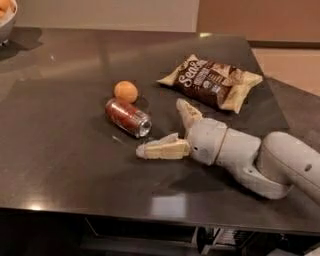

In [2]:
dataset["train"][0]["frame_3"]

In [3]:
def convert_to_conversation(sample):
    instruction = sample["instruction"]
    success = sample["success"]

    prompt = f"""Here is a sequence of frames from a robot policy which has been \
rolled out in a video-generation-based world model. I need your help \
determining whether the policy is successful. How successfully does \
the robot complete the following task?

Task: "{instruction}"

Score rubric:
0 = Failure: instruction "{instruction}" not completed.
1 = Success: instruction completed."""

    response = "1" if success else "0"

    conversation = [
        { "role": "user",
          "content" : [
            {"type" : "text",  "text"  : prompt},
            {"type" : "image", "image" : sample["frame_0"]},
            {"type" : "image", "image" : sample["frame_1"]},
            {"type" : "image", "image" : sample["frame_2"]},
            {"type" : "image", "image" : sample["frame_3"]},
          ]
        },
        { "role" : "assistant",
          "content" : [
            {"type" : "text",  "text"  : response} ]
        },
    ]
    return { "messages" : conversation }

train_dataset = [convert_to_conversation(sample) for sample in dataset["train"]]
train_dataset[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Here is a sequence of frames from a robot policy which has been rolled out in a video-generation-based world model. I need your help determining whether the policy is successful. How successfully does the robot complete the following task?\n\nTask: "place coke can upright"\n\nScore rubric:\n0 = Failure: instruction "place coke can upright" not completed.\n1 = Success: instruction completed.'},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=320x256>},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=320x256>},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=320x256>},
    {'type': 'image',
     'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=320x256>}]},
  {'role': 'assistant', 'content': [{'type': 'text', 'text': '0'}]}]}

In [ ]:
import random
from IPython.display import display, Markdown

def preview_random_conversation():
    sample = train_dataset[random.randint(0, len(train_dataset) - 1)]
    msgs = sample["messages"]
    user_content = msgs[0]["content"]
    assistant_content = msgs[1]["content"]

    # Display prompt text
    prompt_text = user_content[0]["text"]
    display(Markdown(f"**User prompt:**\n\n```\n{prompt_text}\n```"))

    # Display frames side by side
    images = [item["image"] for item in user_content if item["type"] == "image"]
    fig, axes = __import__("matplotlib").pyplot.subplots(1, len(images), figsize=(16, 4))
    if len(images) == 1:
        axes = [axes]
    for i, (ax, img) in enumerate(zip(axes, images)):
        ax.imshow(img)
        ax.set_title(f"Frame {i}")
        ax.axis("off")
    __import__("matplotlib").pyplot.tight_layout()
    __import__("matplotlib").pyplot.show()

    # Display response
    response = assistant_content[0]["text"]
    label = "Success" if response == "1" else "Failure"
    display(Markdown(f"**Assistant response:** `{response}` ({label})"))

preview_random_conversation()